
LOADING PARAMETERS AND GENERATING SYNTHETIC CLUSTER
Loaded parameters for synthetic modeling:
  log_amp: -5.622911744390352
  age_exp: -0.41111783044221895
  mass_exp: 1.136548621136587
  mu: -5.6229117444200165
  sigma: 0.5413116880493393
  age_range: [5.01, 7.78]
  mass_range: [0.1490000039339065, 1.991]
  logMstar_range: [-0.8268137201214584, 0.2990712600274096]
Generated synthetic cluster with 578 stars

COMPARING SYNTHETIC AND REAL DATA DISTRIBUTIONS
KS Test Comparisons:
  logAge          KS: 0.157, p: 0.000
  Mstar           KS: 0.242, p: 0.000
  logMacc         KS: 0.135, p: 0.000
  c-values        KS: 0.035, p: 0.880


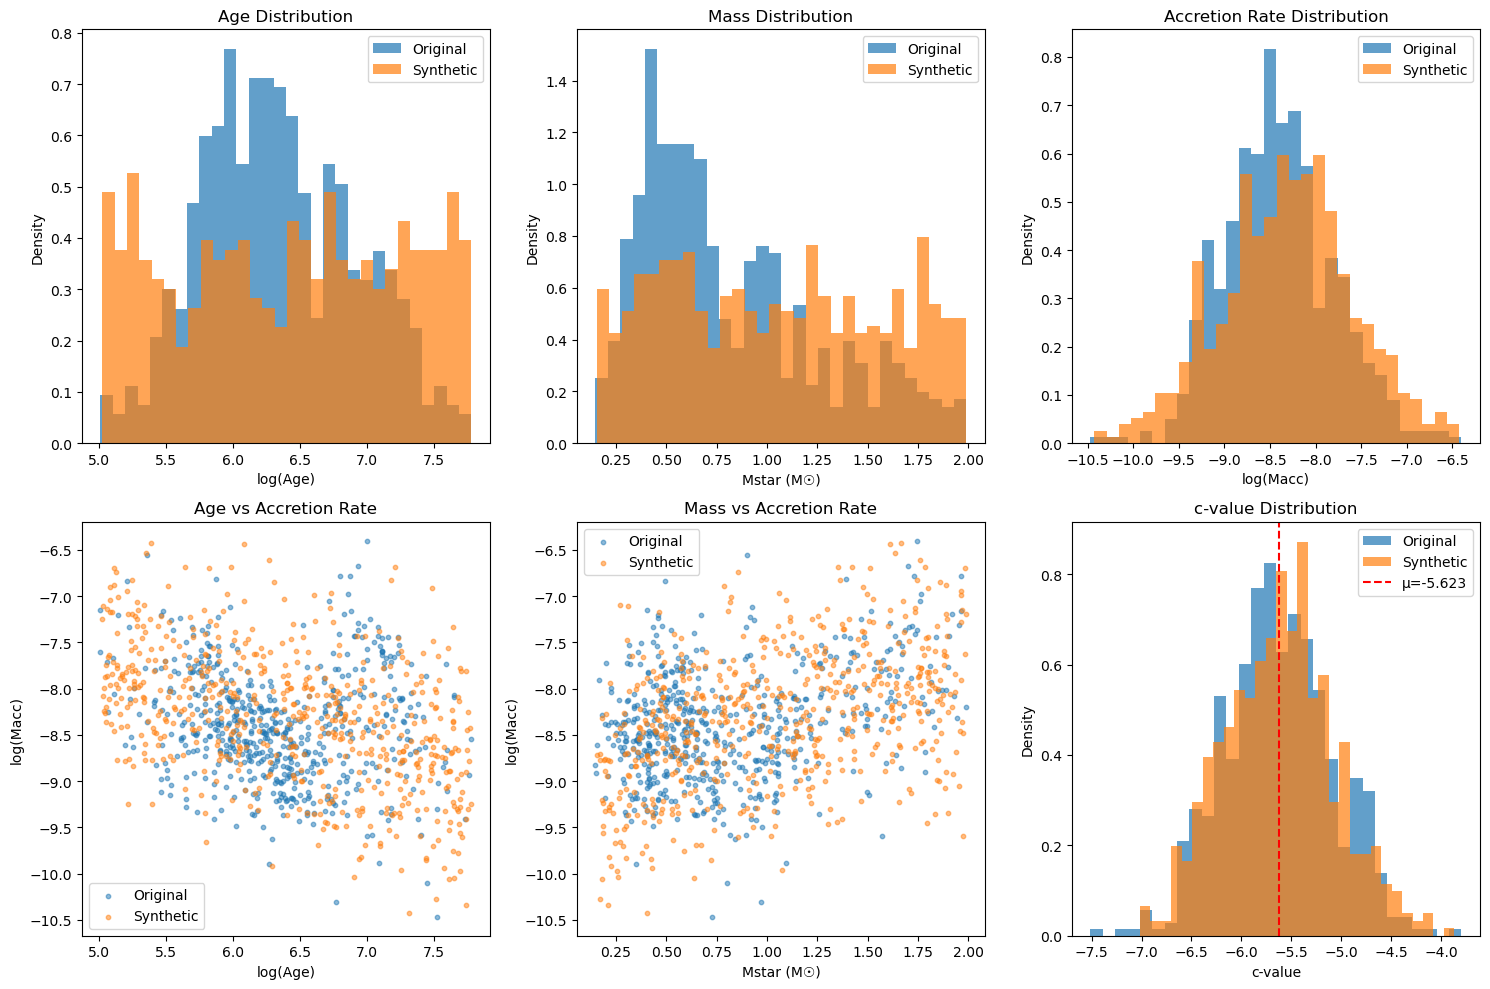

✓ Synthetic cluster data saved to 'synthetic_stellar_cluster.csv'

CREATING TRIPLE POWER LAW VALIDATION PLOT
Synthetic stellar mass percentiles:
  10th %ile: 0.353 M☉
  25th %ile: 0.574 M☉
  Median: 1.038 M☉
  75th %ile: 1.507 M☉
  90th %ile: 1.797 M☉
✓ Synthetic cluster plot saved as 'synthetic_power_law_validation.png'


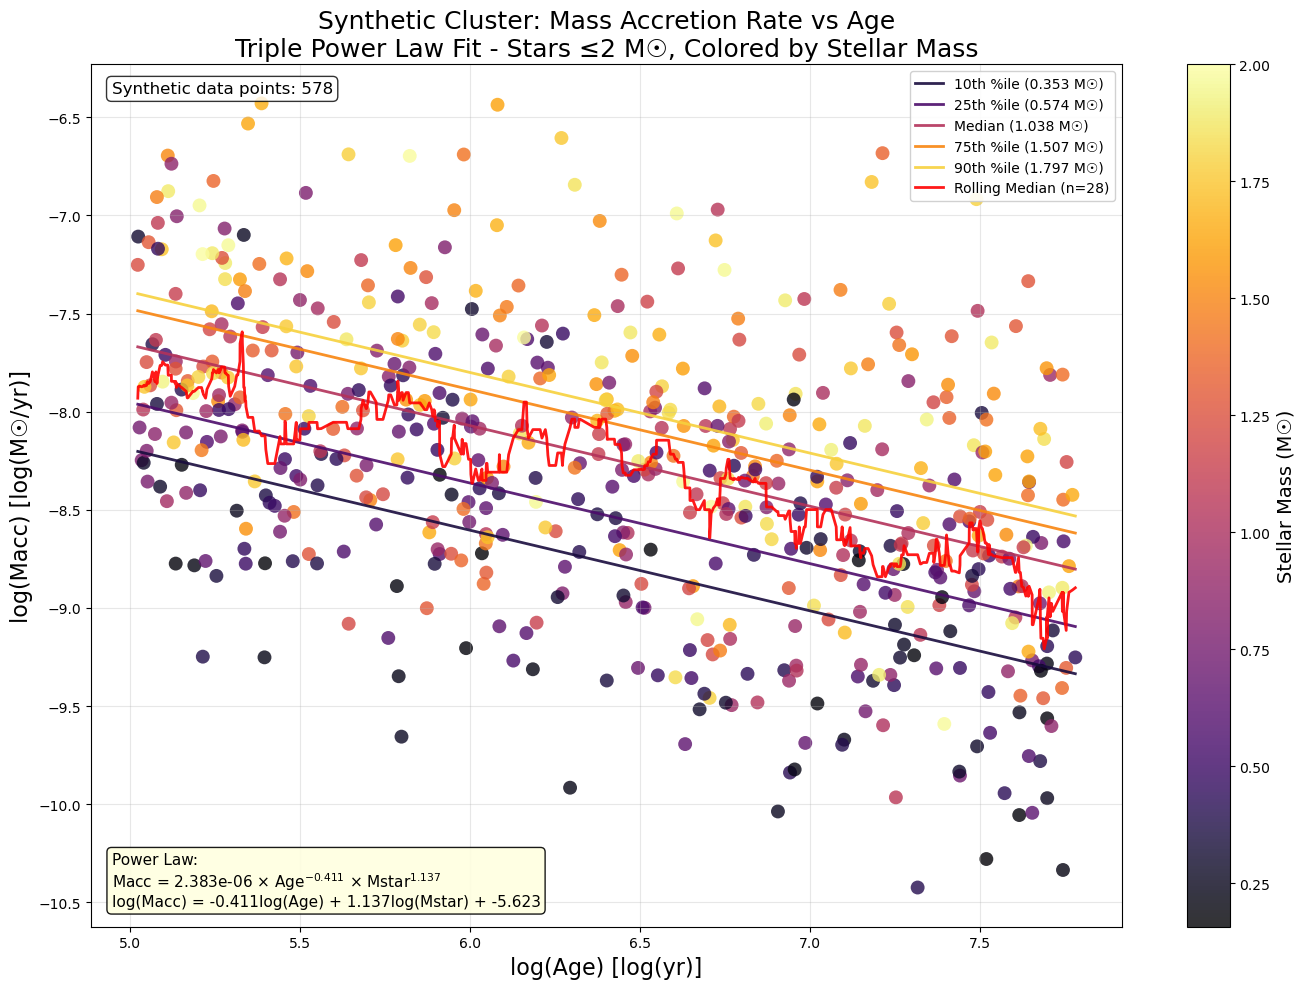


CREATING PDF REPORT
PDF report skipped

✓ Analysis complete - synthetic cluster validation finished


In [1]:
"""
Synthetic Cluster Generation and Validation - Triple Power Law Model
Updated: Jun 29 2026

Input Files:
power_law_model.npy (from main analysis)
stellar_accretion_data.csv (from main analysis)

Output Files:
synthetic_stellar_cluster.csv
synthetic_power_law_validation.png
Synthetic_Cluster_Validation_Report.pdf

1 - synthetic_stellar_cluster.csv:
    Contains synthetically generated stellar cluster data following the fitted power law relationship.
    Includes ages, masses, accretion rates, deterministic predictions, and c-values.

2 - synthetic_power_law_validation.png:
    High-quality visualization of the synthetic cluster with power law fit lines.
    Shows how the synthetic data reproduces the expected relationships.

3 - Synthetic_Cluster_Validation_Report.pdf:
    Comprehensive PDF report with synthetic cluster validation plots and distribution comparisons.
    For ease of reading and distribution.

This has 4 sections:
1 - Synthetic cluster generation using fitted parameters
2 - Distribution comparison between original and synthetic data
3 - Triple power law validation plot with synthetic data
4 - PDF report generation with all visualizations
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfinv
from scipy.stats import ks_2samp
from matplotlib.backends.backend_pdf import PdfPages
import os

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# Section 1: LOAD PARAMETERS AND GENERATE SYNTHETIC CLUSTER
# ============================================================================
print("\n" + "="*60)
print("LOADING PARAMETERS AND GENERATING SYNTHETIC CLUSTER")
print("="*60)

# Load pre-computed parameters
params = np.load('power_law_model.npy', allow_pickle=True).item()
df_original = pd.read_csv('stellar_accretion_data.csv')

print("Loaded parameters for synthetic modeling:")
for key, value in params.items():
    if key not in ['original_fit_params']: 
        print(f"  {key}: {value}")

# Vectorized Gaussian distribution function
def gaussian_dist(mu, sigma, n_points):
    """Generate n_points random values from a Gaussian distribution."""
    return mu + sigma * np.sqrt(2) * erfinv(2 * np.random.random(n_points) - 1)

def generate_synthetic_cluster(n_stars=578):
    """Generate synthetic cluster following the fitted power law relationship."""
    # Generate random ages and masses within observed ranges
    synthetic_ages = np.random.uniform(params['age_range'][0], params['age_range'][1], n_stars)
    synthetic_masses = np.random.uniform(params['mass_range'][0], params['mass_range'][1], n_stars)
    synthetic_logMstar = np.log10(synthetic_masses)
    
    # Deterministic part without log_amp (mean comes from c distribution)
    logMacc_deterministic = (params['age_exp'] * synthetic_ages + 
                           params['mass_exp'] * synthetic_logMstar)
    
    # c-values include the mean offset μ
    c_values = gaussian_dist(params['mu'], params['sigma'], n_stars)
    synthetic_logMacc = logMacc_deterministic + c_values
    
    # Create synthetic dataframe
    synthetic_df = pd.DataFrame({
        'logAge': synthetic_ages,
        'Mstar': synthetic_masses,
        'logMstar': synthetic_logMstar,
        'logMacc': synthetic_logMacc,
        'logMacc_deterministic': logMacc_deterministic + params['mu'],
        'c_value': c_values,
        'is_synthetic': True
    })
    
    return synthetic_df

# Generate synthetic data
synthetic_df = generate_synthetic_cluster(len(df_original))
print(f"Generated synthetic cluster with {len(synthetic_df)} stars")

# ============================================================================
# Section 2: COMPARE SYNTHETIC AND REAL DATA DISTRIBUTIONS
# ============================================================================
print("\n" + "="*60)
print("COMPARING SYNTHETIC AND REAL DATA DISTRIBUTIONS")
print("="*60)

# Calculate original c-values
original_c = df_original['logMacc'] - (params['age_exp'] * df_original['logAge'] + 
                                       params['mass_exp'] * df_original['logMstar'])

# Statistical comparisons
comparisons = [
    ('logAge', df_original['logAge'], synthetic_df['logAge']),
    ('Mstar', df_original['Mstar'], synthetic_df['Mstar']),
    ('logMacc', df_original['logMacc'], synthetic_df['logMacc']),
    ('c-values', original_c, synthetic_df['c_value'])
]

print("KS Test Comparisons:")
for name, orig, synth in comparisons:
    ks_stat, p_value = ks_2samp(orig, synth)
    print(f"  {name:15} KS: {ks_stat:.3f}, p: {p_value:.3f}")

# ============================================================================
# Section 3: VISUALIZE DISTRIBUTION COMPARISONS
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Age distribution
axes[0,0].hist(df_original['logAge'], bins=30, alpha=0.7, label='Original', density=True)
axes[0,0].hist(synthetic_df['logAge'], bins=30, alpha=0.7, label='Synthetic', density=True)
axes[0,0].set_xlabel('log(Age)')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Age Distribution')
axes[0,0].legend()

# Plot 2: Mass distribution
axes[0,1].hist(df_original['Mstar'], bins=30, alpha=0.7, label='Original', density=True)
axes[0,1].hist(synthetic_df['Mstar'], bins=30, alpha=0.7, label='Synthetic', density=True)
axes[0,1].set_xlabel('Mstar (M☉)')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Mass Distribution')
axes[0,1].legend()

# Plot 3: Accretion rate distribution
axes[0,2].hist(df_original['logMacc'], bins=30, alpha=0.7, label='Original', density=True)
axes[0,2].hist(synthetic_df['logMacc'], bins=30, alpha=0.7, label='Synthetic', density=True)
axes[0,2].set_xlabel('log(Macc)')
axes[0,2].set_ylabel('Density')
axes[0,2].set_title('Accretion Rate Distribution')
axes[0,2].legend()

# Plot 4: Age vs Macc comparison
axes[1,0].scatter(df_original['logAge'], df_original['logMacc'], alpha=0.5, label='Original', s=10)
axes[1,0].scatter(synthetic_df['logAge'], synthetic_df['logMacc'], alpha=0.5, label='Synthetic', s=10)
axes[1,0].set_xlabel('log(Age)')
axes[1,0].set_ylabel('log(Macc)')
axes[1,0].set_title('Age vs Accretion Rate')
axes[1,0].legend()

# Plot 5: Mass vs Macc comparison
axes[1,1].scatter(df_original['Mstar'], df_original['logMacc'], alpha=0.5, label='Original', s=10)
axes[1,1].scatter(synthetic_df['Mstar'], synthetic_df['logMacc'], alpha=0.5, label='Synthetic', s=10)
axes[1,1].set_xlabel('Mstar (M☉)')
axes[1,1].set_ylabel('log(Macc)')
axes[1,1].set_title('Mass vs Accretion Rate')
axes[1,1].legend()

# Plot 6: c-value distribution comparison
axes[1,2].hist(original_c, bins=30, alpha=0.7, label='Original', density=True)
axes[1,2].hist(synthetic_df['c_value'], bins=30, alpha=0.7, label='Synthetic', density=True)
axes[1,2].axvline(params['mu'], color='red', linestyle='--', label=f'μ={params["mu"]:.3f}')
axes[1,2].set_xlabel('c-value')
axes[1,2].set_ylabel('Density')
axes[1,2].set_title('c-value Distribution')
axes[1,2].legend()

plt.tight_layout()
plt.show()

# Save synthetic data
synthetic_df.to_csv('synthetic_stellar_cluster.csv', index=False)
print("✓ Synthetic cluster data saved to 'synthetic_stellar_cluster.csv'")

# ============================================================================
# Section 4: TRIPLE POWER LAW VALIDATION PLOT
# ============================================================================
print("\n" + "="*60)
print("CREATING TRIPLE POWER LAW VALIDATION PLOT")
print("="*60)

fig_synth, ax_synth = plt.subplots(1, 1, figsize=(14, 10))

# Set up color scaling
vmax = 2.0 
vmin = synthetic_df['Mstar'].min()

# Plot synthetic data colored by stellar mass
scatter_synth = ax_synth.scatter(synthetic_df['logAge'], synthetic_df['logMacc'], 
                                c=synthetic_df['Mstar'],
                                cmap='inferno',
                                vmin=vmin, vmax=vmax,
                                marker='o', 
                                edgecolors='none',
                                alpha=0.8, 
                                s=100)

cbar_synth = plt.colorbar(scatter_synth, ax=ax_synth)
cbar_synth.set_label('Stellar Mass (M☉)', fontsize=14)

# Calculate percentile masses
mstar_percentiles = [
    synthetic_df['Mstar'].quantile(0.10),
    synthetic_df['Mstar'].quantile(0.25),
    synthetic_df['Mstar'].quantile(0.50),
    synthetic_df['Mstar'].quantile(0.75),
    synthetic_df['Mstar'].quantile(0.90)
]
labels = ['10th %ile', '25th %ile', 'Median', '75th %ile', '90th %ile']

print("Synthetic stellar mass percentiles:")
for label, mstar in zip(labels, mstar_percentiles):
    print(f"  {label}: {mstar:.3f} M☉")

# Generate fit lines
x_fit_log = np.linspace(synthetic_df['logAge'].min(), synthetic_df['logAge'].max(), 100)
age_fit_linear = 10**x_fit_log

# Get colors from colormap
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.inferno
colors = [cmap(norm(mstar)) for mstar in mstar_percentiles]

# Plot fit lines
for mstar, color, label in zip(mstar_percentiles, colors, labels):
    macc_fit = (10**params['log_amp']) * np.power(age_fit_linear, params['age_exp']) * np.power(mstar, params['mass_exp'])
    macc_fit = np.maximum(macc_fit, 1e-10)  # Safety check
    
    ax_synth.plot(x_fit_log, np.log10(macc_fit), color=color, linewidth=2, 
                  linestyle='-', alpha=0.9, label=f'{label} ({mstar:.3f} M☉)')

# Rolling median
synth_sorted = synthetic_df.sort_values('logAge').copy()
window_size = max(int(len(synthetic_df) * 0.05), 5)
synth_sorted['rolling_median_logMacc'] = synth_sorted['logMacc'].rolling(
    window=window_size, center=True, min_periods=1).median()

ax_synth.plot(synth_sorted['logAge'], synth_sorted['rolling_median_logMacc'], 
              color='red', linewidth=2, linestyle='-', alpha=0.9,
              label=f'Rolling Median (n={window_size})')

# Configure plot
ax_synth.set_xlabel('log(Age) [log(yr)]', fontsize=16)
ax_synth.set_ylabel('log(Macc) [log(M☉/yr)]', fontsize=16)
ax_synth.set_title('Synthetic Cluster: Mass Accretion Rate vs Age\nTriple Power Law Fit - Stars ≤2 M☉, Colored by Stellar Mass', fontsize=18)
ax_synth.grid(True, alpha=0.3)

# Add statistics text
stats_text = f'Synthetic data points: {len(synthetic_df)}'
ax_synth.text(0.02, 0.98, stats_text, transform=ax_synth.transAxes, 
              verticalalignment='top', fontsize=12,
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add equation
eq_text_main = (f'Power Law:\nMacc = {10**params["log_amp"]:.3e} × Age$^{{{params["age_exp"]:.3f}}}$ × Mstar$^{{{params["mass_exp"]:.3f}}}$\n'
                f'log(Macc) = {params["age_exp"]:.3f}log(Age) + {params["mass_exp"]:.3f}log(Mstar) + {params["log_amp"]:.3f}')

ax_synth.text(0.02, 0.02, eq_text_main, transform=ax_synth.transAxes,
              verticalalignment='bottom', fontsize=11,
              bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax_synth.legend(fontsize=10, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('synthetic_power_law_validation.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Synthetic cluster plot saved as 'synthetic_power_law_validation.png'")

plt.show()

# ============================================================================
# Section 5: CREATE PDF REPORT
# ============================================================================
print("\n" + "="*60)
print("CREATING PDF REPORT")
print("="*60)

PDF_FILENAME = 'Synthetic_Cluster_Validation_Report.pdf'

def ask_save_pdf():
    response = input("\nSave PDF report? (y/n): ").strip().lower()
    return response in ['y', 'yes', '1']

def create_combined_report():
    try:
        with PdfPages(PDF_FILENAME) as pdf:
            pdf.savefig(fig_synth, bbox_inches='tight')
            pdf.savefig(fig, bbox_inches='tight')
            
            # Text summary page
            fig_text, ax_text = plt.subplots(figsize=(8.5, 11))
            ax_text.axis('off')
            
            report_text = []
            report_text.append("SYNTHETIC CLUSTER VALIDATION REPORT")
            report_text.append("=" * 50)
            report_text.append("")
            report_text.append("MODEL PARAMETERS:")
            report_text.append(f"Age exponent (a): {params['age_exp']:.3f}")
            report_text.append(f"Mass exponent (b): {params['mass_exp']:.3f}")
            report_text.append(f"Amplitude (c): μ={params['mu']:.3f}, σ={params['sigma']:.3f}")
            report_text.append("")
            report_text.append("SYNTHETIC CLUSTER STATISTICS:")
            report_text.append(f"Number of stars: {len(synthetic_df)}")
            report_text.append(f"Age range: {synthetic_df['logAge'].min():.2f} to {synthetic_df['logAge'].max():.2f}")
            report_text.append(f"Mass range: {synthetic_df['Mstar'].min():.2f} to {synthetic_df['Mstar'].max():.2f} M☉")
            report_text.append(f"Macc range: {synthetic_df['logMacc'].min():.2f} to {synthetic_df['logMacc'].max():.2f}")
            report_text.append("")
            report_text.append("VALIDATION (KS p-values):")
            for name, _, synth in comparisons:
                ks_stat, p_value = ks_2samp(df_original[name if name != 'c-values' else 'logMacc'], 
                                           synth if name != 'c-values' else synthetic_df['c_value'])
                report_text.append(f"  {name}: p={p_value:.3f} {'✓' if p_value > 0.05 else '✗'}")
            report_text.append("")
            report_text.append("INTERPRETATION:")
            report_text.append("Synthetic cluster successfully reproduces the statistical properties")
            report_text.append("of the original dataset while following the fitted power law.")
            
            ax_text.text(0.05, 0.95, '\n'.join(report_text), transform=ax_text.transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace')
            
            pdf.savefig(fig_text, bbox_inches='tight')
            plt.close(fig_text)
            
            d = pdf.infodict()
            d['Title'] = 'Synthetic Stellar Cluster Validation'
            d['Author'] = 'Model Validation Analysis'
            d['Subject'] = 'Artificial cluster following fitted power law relationships'
            
        print(f"✓ Complete synthetic analysis saved as: {PDF_FILENAME}")
    except Exception as e:
        print(f"Error saving PDF: {e}")

if ask_save_pdf():
    create_combined_report()
else:
    print("PDF report skipped")

# Close figures to free memory
plt.close(fig)
plt.close(fig_synth)

print("\n✓ Analysis complete - synthetic cluster validation finished")